# Context engineering vs. agent memory: a head-to-head test

This notebook backs the post *"Measuring the crossover from context engineering to agent memory."*

The question: when an agent needs to recall something a user said many turns ago, should you
solve that by getting smarter about what you stuff into the context window (**context engineering**),
or by writing facts out to an external store and retrieving them (**agent memory**)?

The harness builds a synthetic long-running conversation with 40 facts scattered through it, then test three ways of answering follow-up questions about
those facts:

1. **Recency truncation**: naive baseline, just keep the last N turns.
2. **Context packing**: score the *raw conversation history* against the query (TF-IDF
   relevance) and pack the highest-scoring turns into a fixed token budget. This is a real
   context-engineering technique, not a strawman.
3. **Memory retrieval**: extract facts into a small external store as the conversation happens,
   then score *only that store* against the query.

We measure recall (did the fact-bearing turn make it into the assembled context?) and a compute
proxy (how many turns had to be scored) as the conversation grows from 80 to 800 turns.

Two settings decide whether this measures retrieval at all. Both fail quietly, producing clean
and meaningless numbers, so they are worth checking in any retrieval evaluation:

- **40 facts, not 10.** The extracted store has to be *bigger than the token budget*, otherwise
  `approach_memory_retrieval` just packs the entire store every time and its ranking step never
  decides anything. Ten facts would come to 113 tokens against a 120-token budget: the store would
  always fit, so perfect recall would measure the budget rather than the retrieval. At 40 facts the
  store is ~434 tokens and at most 12 fit, so ranking determines the result.
- **A hit means the fact-bearing turn is present**, not that an expected substring appears
  somewhere in the assembled text. Substring matching invents hits: `"IST"` is a substring of
  `"list"`, and both `"list"` and `"Python"` occur in the filler pool, so two facts could register
  a hit off a filler turn with nothing retrieved at all.


## Setup

In [1]:
import sys
sys.path.append("src")
from sim import (
    FACTS, QUERIES, PARAPHRASED_QUERIES, SWEEP_LENGTHS, approx_tokens,
    generate_conversation, extract_memory_store,
    approach_recency, approach_context_packing, approach_memory_retrieval,
    run_eval,
)
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
print(f"{len(FACTS)} facts tracked, {len(QUERIES)} recall queries, "
      f"{len(PARAPHRASED_QUERIES)} paraphrased queries")


40 facts tracked, 40 recall queries, 40 paraphrased queries


## Look at one synthetic conversation

Facts are scattered through the conversation with unrelated filler turns padding it out, the
same way real facts (a user ID, a preference, a deadline) show up once in a much longer
conversation about other things.


In [2]:
convo = generate_conversation(num_turns=120, seed=7)
for t in convo[:12]:
    marker = "  <-- FACT" if t.is_fact else ""
    print(f"[{t.index:3d}] {t.speaker:9s} {t.text}{marker}")
print("...")


[  0] user      I need to write a unit test for this function.
[  1] user      By the way, the vendor contract renews in March.  <-- FACT
[  2] user      What's causing this merge conflict?
[  3] user      By the way, our coverage threshold is 82 percent.  <-- FACT
[  4] user      How should I structure logging for this service?
[  5] assistant What's the difference between a list and a tuple in Python?
[  6] user      Can you help me debug this stack trace from last night's deploy?
[  7] user      By the way, my team has 9 engineers.  <-- FACT
[  8] user      What's causing this merge conflict?
[  9] user      By the way, the main repo is called orion-gateway.  <-- FACT
[ 10] user      What's causing this merge conflict?
[ 11] assistant How do I set up a virtual environment for this repo?
...


## The three approaches, on a single query

Before running the full sweep, sanity-check each approach against one question on this
120-turn conversation.


In [3]:
memory_store = extract_memory_store(convo)
store_tokens = sum(approx_tokens(t.text) for t in memory_store)
print(f"Memory store size: {len(memory_store)} entries (vs. {len(convo)} raw turns)")
print(f"Memory store tokens: {store_tokens} against a 120-token budget "
      f"-- fits whole: {store_tokens <= 120}")
print("(if it fitted whole, retrieval would never have to rank anything)\n")

question = "What's my employee ID?"
budget = 120

text, tokens, scored = approach_recency(convo, budget)
print("RECENCY TRUNCATION")
print(f"  turns scored: {scored} | tokens used: {tokens}")
print(f"  answer present: {'e-77210' in text.lower()}\n")

text, tokens, scored = approach_context_packing(convo, question, budget, max_scorable_history=300)
print("CONTEXT PACKING (full-history relevance scoring)")
print(f"  turns scored: {scored} | tokens used: {tokens}")
print(f"  answer present: {'e-77210' in text.lower()}\n")

text, tokens, scored = approach_memory_retrieval(memory_store, question, budget)
print("MEMORY RETRIEVAL (external store)")
print(f"  turns scored: {scored} | tokens used: {tokens}")
print(f"  answer present: {'e-77210' in text.lower()}")


Memory store size: 40 entries (vs. 120 raw turns)
Memory store tokens: 434 against a 120-token budget -- fits whole: False
(if it fitted whole, retrieval would never have to rank anything)

RECENCY TRUNCATION
  turns scored: 0 | tokens used: 119
  answer present: False

CONTEXT PACKING (full-history relevance scoring)
  turns scored: 120 | tokens used: 118
  answer present: True

MEMORY RETRIEVAL (external store)
  turns scored: 40 | tokens used: 118
  answer present: True


At 120 turns the two scored approaches keep up and recency truncation is already missing most
facts. The real test is what happens as the conversation keeps growing.

## Sweep across conversation lengths

Same 40 facts, same 40 queries, run against conversations from 80 to 800 turns. (The sweep starts
at 80 rather than 20 because 40 facts need at least 80 turns to scatter with padding.) Each
approach gets a fixed 120-token budget for the assembled context. Context packing additionally has
a `max_scorable_history=300` cap, which stands in for the real ceiling on how much raw history you can
even feed into a single scoring pass (context-window or cost limit on the ranking step itself).


In [4]:
rows = run_eval(
    conversation_lengths=SWEEP_LENGTHS,
    token_budget=120,
    seed=7,
    max_scorable_history=300,
)
df = pd.DataFrame(rows)

summary = df.groupby(["conversation_length", "approach"]).agg(
    recall=("hit", "mean"),
    avg_tokens_used=("tokens_used", "mean"),
    avg_turns_scored=("turns_scored", "mean"),
).reset_index()

summary.pivot(index="conversation_length", columns="approach", values="recall")


approach,context_packing,memory_retrieval,recency_truncation
conversation_length,,,
80,1.000,1.0,0.125
120,1.000,1.0,0.100
240,1.000,1.0,0.050
480,0.625,1.0,0.025
800,0.375,1.0,0.025


### Recall as the conversation grows

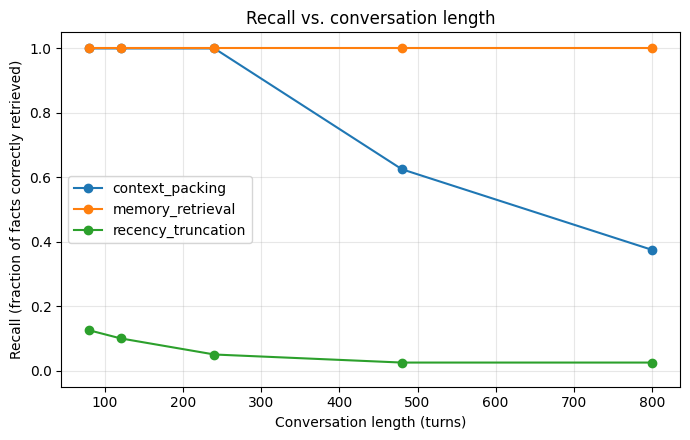

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for approach, group in summary.groupby("approach"):
    ax.plot(group["conversation_length"], group["recall"], marker="o", label=approach)
ax.set_xlabel("Conversation length (turns)")
ax.set_ylabel("Recall (fraction of facts correctly retrieved)")
ax.set_title("Recall vs. conversation length")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/recall_vs_length.png", dpi=150)
plt.show()


### Compute cost (turns scored) as the conversation grows

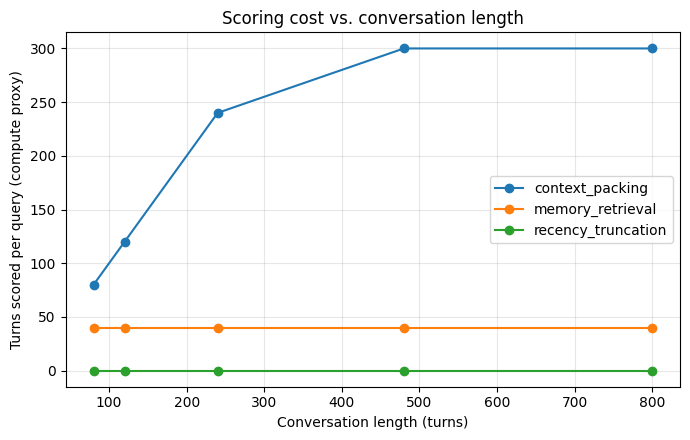

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for approach, group in summary.groupby("approach"):
    ax.plot(group["conversation_length"], group["avg_turns_scored"], marker="o", label=approach)
ax.set_xlabel("Conversation length (turns)")
ax.set_ylabel("Turns scored per query (compute proxy)")
ax.set_title("Scoring cost vs. conversation length")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/cost_vs_length.png", dpi=150)
plt.show()


## Reading the results

- **Recency truncation** is hopeless almost immediately. With 40 facts scattered through the
  history and a 120-token window, recall starts at 0.125 and falls to 0.025. It is keeping the
  most recent turns, and the facts are almost never in them.
- **Context packing** is genuinely good, not a strawman: while the raw history still fits inside
  the scoring cap (up to 240 turns here), it hits perfect recall, because relevance-scored packing
  correctly finds and prioritizes the fact-bearing turns. But once the conversation exceeds
  `max_scorable_history`, older facts become *invisible to the scorer itself* (not just
  de-prioritized), and recall falls to 0.625, then 0.375. Cost also grows directly with
  conversation length until it hits the cap.
- **Memory retrieval** holds perfect recall throughout, and its cost (turns scored) stays flat at
  40 the whole time, because it's scoring a small, curated store instead of the raw conversation.

Memory retrieval's 1.0 is earned rather than free: the store is ~434 tokens against
a 120-token budget, so it has to rank 40 candidates and land the right one in the top ~12 every
time. You can check that ranking is load-bearing by handing it a nonsense query: it returns a
partial, arbitrary slice of the store rather than all of it.

This matches what shows up in production: context engineering (smart packing of what's already in
front of you) is the right tool when the working set is bounded. Once the history genuinely
outgrows what you can afford to look at each turn, you need a separate, bounded store that's
maintained incrementally. That is agent memory.


## Does a real embeddings model change the answer?

Everything above scores relevance with TF-IDF, which matches on literal word overlap. A real
embeddings model matches on meaning. `src/local_backend.py` swaps one in: `BAAI/bge-small-en-v1.5`
running on CPU through [fastembed](https://github.com/qdrant/fastembed). The model (~130MB)
downloads on first use and is cached, so later runs need no network.

Every approach takes a `scorer` argument with a single contract, so nothing else changes.

There is a trap here worth being explicit about. The `QUERIES` above mostly *reuse the words of the
fact they ask about*. "Who is my manager?" against "my manager's name is Priya Raman" shares the
word *manager*. That hands a lexical scorer the answer, and it means TF-IDF and a real embeddings
model look identical. `PARAPHRASED_QUERIES` asks for the same 40 facts using none of the fact's own
vocabulary ("Who do I report to?"), which is what actually separates them.


In [7]:
from local_backend import LocalEmbeddingScorer

local = LocalEmbeddingScorer()   # downloads ~130MB on first run, then cached
print(f"scorer: {local.model_name}")

comparison = []
for scorer_name, scorer in [("tfidf", None), ("bge-small-en-v1.5", local.rank_by_relevance)]:
    for set_name, qset in [("original", QUERIES), ("paraphrased", PARAPHRASED_QUERIES)]:
        rows_c = run_eval(
            conversation_lengths=[120, 300],
            token_budget=120,
            seed=7,
            max_scorable_history=300,
            query_set=qset,
            scorer=scorer,
        )
        dfc = pd.DataFrame(rows_c)
        agg = dfc[dfc.approach != "recency_truncation"].groupby(
            ["conversation_length", "approach"])["hit"].mean().reset_index()
        for _, r in agg.iterrows():
            comparison.append({
                "scorer": scorer_name,
                "query_set": set_name,
                "turns": r["conversation_length"],
                "approach": r["approach"],
                "recall": r["hit"],
            })

comparison_df = pd.DataFrame(comparison)
comparison_df.pivot_table(index=["scorer", "query_set", "turns"],
                          columns="approach", values="recall")


/Users/rahulsharma/blogs/blog/context-vs-memory/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


scorer: BAAI/bge-small-en-v1.5


approach                             context_packing  memory_retrieval
scorer            query_set   turns                                   
bge-small-en-v1.5 original    120              1.000              1.00
                              300              1.000              1.00
                  paraphrased 120              0.525              0.85
                              300              0.450              0.85
tfidf             original    120              1.000              1.00
                              300              1.000              1.00
                  paraphrased 120              0.225              0.35
                              300              0.250              0.35

Two things to take from that table.

**On the original queries the two scorers are indistinguishable, and both perfect.** Real embeddings
change nothing, because those questions were written using the fact's own words. If you only ever
evaluate with questions phrased like the text you are searching, you will conclude your retrieval
is solved and that embeddings are not worth the dependency. That conclusion is an artifact of the
eval.

**On paraphrased queries the gap is large.** TF-IDF drops to roughly 0.23 to 0.25 for context packing
and 0.35 for memory retrieval; the embedding model recovers to about 0.45 to 0.53 and 0.85. Semantic
scoring is doing real work, and note it helps memory retrieval most, because that lane is pure
ranking over a bounded store, which is exactly what a better scorer improves. It does not rescue
context packing at 800 turns, because no amount of ranking quality reaches a turn the scorer never
saw.


## Caveat: the memory store here uses a perfect extractor

`extract_memory_store()` pulls out exactly the turns we tagged as fact-bearing at generation time.
That's an oracle, not a real extraction pipeline. In production, a memory-writing step (usually an
LLM call) has to *decide* what's worth remembering, and it will miss things, misfile things, or
write down something slightly wrong. None of that lossiness shows up here. The comparison in this
notebook isolates the retrieval/scaling question; it does not tell you how much accuracy you'll
give up to a real extractor, which is the one remaining place where these numbers flatter memory
retrieval.

`src/eval_lossy_extraction.py` puts a number on it by dropping a share of facts before they reach
the store. Memory retrieval's recall collapses to roughly its extraction quality, flat across every
length, because a dropped fact is absent rather than hard to find. Context packing has no
extraction step, so the two are not penalised symmetrically: at 60% extraction memory loses at 480
turns and only wins at 800.

Two traps worth carrying into any retrieval evaluation, since both are easy to introduce and
neither announces itself:

- **A memory store that fits inside the token budget measures nothing.** If the whole store gets
  packed every time, the retrieval step is decorative and its recall is 1.0 by construction. Check
  the store's token count against the budget before believing any retrieval number.
- **Substring hit-detection invents hits.** Matching `"IST"` against the assembled text also
  matches `"list"`. Match on the retrieved unit itself.
